# Movie Review Sentiment Analysis using RNN (LSTM)

<span style="font-size:20px">

This project focuses on building a deep learning model to classify movie reviews as **positive or negative**.

Natural Language Processing (NLP) techniques and Recurrent Neural Networks (RNN) are used to understand the sentiment expressed in textual data.

The model learns patterns in reviews and predicts whether a given review expresses **positive or negative sentiment**.

</span>

## Problem Statement

<span style="font-size:20px">

Movie reviews often contain opinions that express whether a viewer liked or disliked a movie.
Manually analyzing thousands of reviews is time-consuming and inefficient.

The goal of this project is to build a model that can automatically determine the sentiment of a movie review.

</span>

### Input
<span style="font-size:18px">
Movie review text
</span>

### Output
<span style="font-size:18px">

Sentiment classification
• Positive
• Negative

</span>

### Examples

<span style="font-size:18px">

Example 1
Review: "The movie was fantastic and the acting was brilliant."
Sentiment: Positive

Example 2
Review: "The movie was boring and a complete waste of time."
Sentiment: Negative

</span>

## What is RNN?

<span style="font-size:20px">

A Recurrent Neural Network (RNN) is a type of neural network designed to process **sequential data**.

Unlike traditional neural networks, RNNs maintain a **memory of previous inputs**, allowing them to capture relationships between words in a sequence.

RNNs are commonly used for tasks involving sequential information such as:
• Text processing
• Speech recognition
• Time series prediction

</span>

### Examples

<span style="font-size:18px">

Example 1
"I did not like the movie"

Example 2
"The movie started slow but the ending was amazing"

</span>

## What is LSTM?

<span style="font-size:20px">

LSTM (Long Short-Term Memory) is a special type of RNN designed to learn **long-term dependencies** in sequences.

Traditional RNNs struggle with remembering earlier information due to the **vanishing gradient problem**.
LSTM solves this using gates that control how information is stored, forgotten, and passed forward.

These gates allow the model to retain important context from earlier parts of a sentence.

</span>

### Examples

<span style="font-size:18px">

Example 1
"The movie was not bad"

Example 2
"I expected the movie to be terrible but it turned out great"

</span>

In [ ]:
import pandas as pd
from bs4 import BeautifulSoup
import string
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df=pd.read_csv('./data/IMDB Dataset.csv')

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
df['sentiment'].value_counts()

## Natural Language Toolkit (NLTK)

<span style="font-size:20px">

**NLTK (Natural Language Toolkit)** is a Python library used for **Natural Language Processing (NLP)** tasks.

It provides tools and libraries that help in processing, analyzing, and working with human language data such as text.

In this project, NLTK is used to **preprocess movie review text before feeding it into the neural network model.**

</span>

### Why NLTK is Used

<span style="font-size:20px">

• Helps clean and preprocess raw text data

• Converts text into a structured format that machine learning models can understand

• Provides built-in utilities for common NLP operations

</span>

### Tasks Performed Using NLTK

<span style="font-size:20px">

• Tokenization – Splitting text into individual words

• Stopword Removal – Removing common words like *the, is, and*

• Stemming – Reducing words to their root form

• Text Cleaning – Removing punctuation and unwanted characters

</span>

### Example 1

<span style="font-size:20px">

Original Sentence
"The movie was absolutely amazing and very entertaining"

After Preprocessing
movie absolutely amazing entertaining

</span>

### Example 2

<span style="font-size:20px">

Original Sentence
"I was not impressed with the storyline"

After Preprocessing
not impressed storyline

</span>

In [ ]:
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')

## Removing HTML Tags

Some movie reviews contain HTML tags like `<br>` or `<p>` because the data is taken from websites.

These tags do not help in sentiment analysis and only add unnecessary text.
So, we remove HTML tags during preprocessing to keep only the actual review content.

Example

Original Review
`<br>This movie was amazing and very entertaining<br>`

After Removing HTML Tags
This movie was amazing and very entertaining

In [ ]:
def text_cleaning(text):
    text=BeautifulSoup(text,"html.parser").get_text()
    text=text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

In [ ]:
df['review']=df['review'].apply(text_cleaning)

## Stemming Words

Stemming is a text preprocessing technique used to reduce words to their root or base form.

This helps reduce the number of unique words in the dataset and makes it easier for the model to learn patterns.

Example

Original Sentence
I loved loving the movie because it was loved by everyone

After Stemming
love love the movi becaus it wa love by everyon

In [ ]:
ps=PorterStemmer()
def stem_text(text):
    tokens=word_tokenize(text)
    stemmed=[ps.stem(word) for word in tokens]
    return " ".join(stemmed)

In [ ]:
df['review']=df['review'].apply(stem_text)

In [ ]:
df.head()

## Stop Words Removal

Stop words are common words that appear frequently in sentences but usually do not add important meaning for sentiment analysis.

Examples of stop words include words like **the, is, and, was, in, at, on**.

Removing these words helps reduce noise in the dataset and allows the model to focus on meaningful words.

Example

Original Sentence
The movie was very interesting and the story was great

After Removing Stop Words
movie very interesting story great

In [ ]:
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words=set(stopwords.words('english'))

In [ ]:
def remove_stopwords(text):
    tokens=word_tokenize(text)
    filtered_words=[word for word in tokens if word.lower() not in stop_words]
    return " ". join(filtered_words)

In [ ]:
df['review']=df['review'].apply(remove_stopwords)

## Label Encoding Target Column

Label encoding is used to convert categorical labels into numerical values so that machine learning models can process them.

In this project, the sentiment labels (positive and negative) are converted into numbers.

Positive reviews are encoded as **1** and negative reviews are encoded as **0**.


In [ ]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

df['sentiment']=le.fit_transform(df['sentiment'])

In [ ]:
from sklearn.model_selection import train_test_split

x=df['review']
y=df['sentiment']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import  pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense,LSTM,Dropout,Conv1D,Bidirectional,MaxPooling1D

## Tokenization and Padding Sequences

Tokenization is the process of converting text into numerical tokens so that it can be processed by a neural network.

The tokenizer assigns a unique integer to each word in the vocabulary.

Padding is then applied to ensure that all sequences have the same length. Shorter sequences are padded with zeros.

Example

Original Sentence
This movie was amazing

After Tokenization
[12, 45, 7, 89]

After Padding (length = 6)
[0, 0, 12, 45, 7, 89]

In [ ]:
tokenizer=Tokenizer(num_words=10000)
tokenizer.fit_on_texts(x_train)

x_train_seq=tokenizer.texts_to_sequences(x_train)
x_test_seq=tokenizer.texts_to_sequences(x_test)

In [ ]:
max_len=200
x_train_pad=pad_sequences(x_train_seq,maxlen=max_len)
x_test_pad=pad_sequences(x_test_seq,maxlen=max_len)

In [ ]:
print(len(x_train_pad))
print(len(y_train))

In [ ]:
print(x_train_pad.shape)
print(y_train.shape)

## Attempt 1 – Using a Single RNN Layer

In the first attempt, a simple Recurrent Neural Network (RNN) with only **one RNN layer** was used to perform sentiment analysis on movie reviews.

The goal of this attempt was to understand how a basic RNN handles sequential text data.

Model Structure

- Embedding Layer – Converts words into numerical vectors
- Single SimpleRNN Layer – Processes the sequence of words
- Dense Output Layer – Predicts the sentiment (positive or negative)


In [ ]:
model=Sequential()

model.add(Embedding(input_dim=10000,output_dim=64,input_length=max_len))
model.add(SimpleRNN(64))
model.add(Dense(1,activation='sigmoid'))


In [ ]:
model.summary()

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(x_train_pad,y_train,epochs=5,batch_size=64,validation_data=(x_test_pad,y_test))

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')

plt.legend()
plt.show()


# Loss plot
plt.figure()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')

plt.legend()
plt.show()

## Attempt 2 – Using Stacked LSTM Layers

In the second attempt, the model was improved by replacing the simple RNN with **stacked LSTM layers**.
LSTM networks are better at capturing long-term dependencies in text compared to basic RNNs.

The model uses an embedding layer followed by two LSTM layers with dropout to reduce overfitting.
Finally, a dense layer with sigmoid activation is used to predict the sentiment of the movie review.

Model Architecture

- Embedding Layer – Converts words into dense vector representations
- LSTM Layer (100 units) – Learns patterns from the sequence
- Dropout (0.5) – Prevents overfitting
- LSTM Layer (100 units) – Extracts deeper sequential features
- Dropout (0.5)
- Dense Layer – Outputs the final sentiment prediction

Example

Input Review
The movie was very interesting and enjoyable

Tokenized Sequence
[34, 12, 9, 76, 5, 210]

The LSTM processes the sequence and predicts whether the sentiment is **positive or negative**.

In [ ]:
model = Sequential()
model.add(Embedding(input_dim=10000,output_dim=64,input_length=max_len))
model.add(LSTM(100, return_sequences = True))
model.add(Dropout(0.5))
model.add(LSTM(100, return_sequences = False))
model.add(Dropout(0.5))
model.add(Dense(1, activation="sigmoid"))
model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics="accuracy")

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(x_train_pad,y_train,epochs=8,batch_size=64,validation_data=(x_test_pad,y_test))

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')

plt.legend()
plt.show()


# Loss plot
plt.figure()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')

plt.legend()
plt.show()

## Keras Tuner

Keras Tuner is a library used to automatically find the best hyperparameters for a deep learning model.

Instead of manually testing different values for parameters like number of layers, units, dropout, or optimizer, Keras Tuner searches for the best combination that gives the highest model performance.

This helps improve the model accuracy and reduces manual trial and error.

Hyperparameters Tuned

- Embedding dimension
- Number of LSTM layers
- Number of units in each LSTM layer
- Dropout rate
- Optimizer

Example

Trial 1
embedding_dim = 64
lstm_units = 64
dropout = 0.3

Trial 2
embedding_dim = 128
lstm_units = 100
dropout = 0.5

Keras Tuner evaluates multiple combinations and selects the configuration that gives the best validation performance.

In [ ]:
import keras_tuner as kt
from tensorflow.keras.optimizers import Adam, RMSprop
def build_model(hp):
    model=Sequential()
    model.add(Embedding(input_dim=10000,output_dim=hp.Choice("embedding_dim",[32,64,128]),input_length=max_len))
    num_layers=hp.Int("num_layers",1,3)
    for i in range(num_layers):
        if i ==num_layers-1:
            model.add(LSTM(units=hp.Choice(f"lstm_units_{i}",[32,64,128]),return_sequences=False))
        else:
            model.add(LSTM(units=hp.Choice(f"lstm_units_{i}",[32,64,128]),return_sequences=True))
        model.add(Dropout(hp.Choice(f"dropout_{i}",[0.2,0.3,0.5])))
    model.add(Dense(1,activation="sigmoid"))
    optimizer_choice = hp.Choice("optimizer",["adam","rmsprop"])
    if optimizer_choice == "adam":
        optimizer = Adam()
    else:
        optimizer = RMSprop()
    model.compile(optimizer=optimizer,loss="binary_crossentropy",metrics=['accuracy'])

    return model

In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=20,
    directory="tuner_results",
    project_name="sentiment_model",
    overwrite=True
)
tuner.search(
    x_train_pad,
    y_train,
    epochs=8,
    validation_data=(x_test_pad,y_test)
)

In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]

In [ ]:
best_model

In [ ]:
tuner.get_best_hyperparameters()[0].values

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
callbacks = [early_stopping]

In [86]:
model = Sequential()

model.add(Embedding(input_dim=20000, output_dim=128, input_length=200))

model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))

model.add(MaxPooling1D(pool_size=2))

model.add(Bidirectional(LSTM(64)))

model.add(Dropout(0.5))

model.add(Dense(64, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test_pad,y_test),
    callbacks=callbacks
)

Epoch 1/10
1250/1250 [==============================] - 124s 97ms/step - loss: 0.3390 - accuracy: 0.8508 - val_loss: 0.2847 - val_accuracy: 0.8855
Epoch 2/10
1250/1250 [==============================] - 206s 165ms/step - loss: 0.2054 - accuracy: 0.9229 - val_loss: 0.2714 - val_accuracy: 0.8902
Epoch 3/10
1250/1250 [==============================] - 166s 133ms/step - loss: 0.1295 - accuracy: 0.9541 - val_loss: 0.2879 - val_accuracy: 0.8839
Epoch 4/10
1250/1250 [==============================] - 101s 81ms/step - loss: 0.0737 - accuracy: 0.9761 - val_loss: 0.3796 - val_accuracy: 0.8832
Epoch 5/10
1250/1250 [==============================] - 101s 81ms/step - loss: 0.0438 - accuracy: 0.9855 - val_loss: 0.4289 - val_accuracy: 0.8833


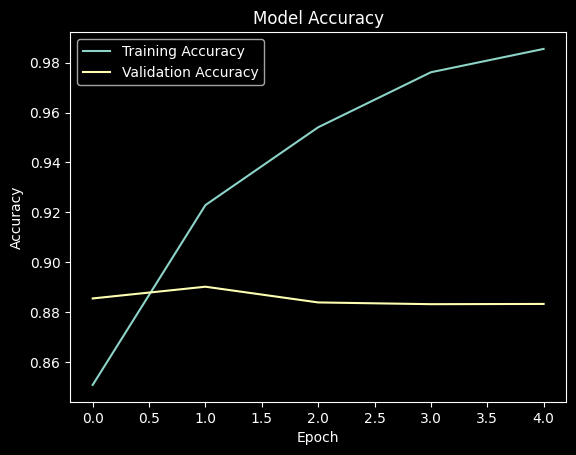

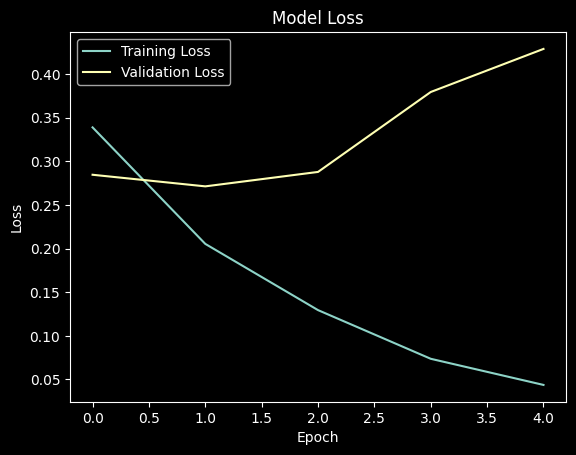

In [88]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')

plt.legend()
plt.show()


# Loss plot
plt.figure()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')

plt.legend()
plt.show()